<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Custom_Solver_for_ADS_Simulation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [2]:
!uv pip install --system -q cupy-cuda12x

GPU: Tesla T4
CuPy: 14.0.1
CUDA runtime: 12090
GPU memory: 14.33 / 14.56 GiB free

Solving nominal substrate cross section...
Box pass 0: 99,824 unknown nodes, boundary field = 0.830%, solve time = 0.444 s

Solving matched vacuum cross section...

Benchmark summary
             metric        graph     analytic  relative_error
C_substrate_f_per_m 1.415721e-10 1.365765e-10    3.657724e-02
   C_vacuum_f_per_m 2.722541e-11 2.626472e-11    3.657724e-02
        epsilon_eff 5.200000e+00 5.200000e+00    2.220446e-15
             Z0_ohm 5.372832e+01 5.569355e+01   -3.528656e-02
 quarter_wave_f0_hz 6.086467e+09 6.086467e+09   -8.881784e-16

Numerical diagnostics
                quantity        value
Energy-charge C mismatch 7.668703e-15
    Boundary field ratio 8.300993e-03
    Active node fraction 5.000937e-02
  Energy in active nodes 9.492029e-01
    CG relative residual 9.746031e-09
     Unknown graph nodes 9.982400e+04
       Sparse matrix nnz 4.971680e+05
    Nominal solve time s 4.439667e-

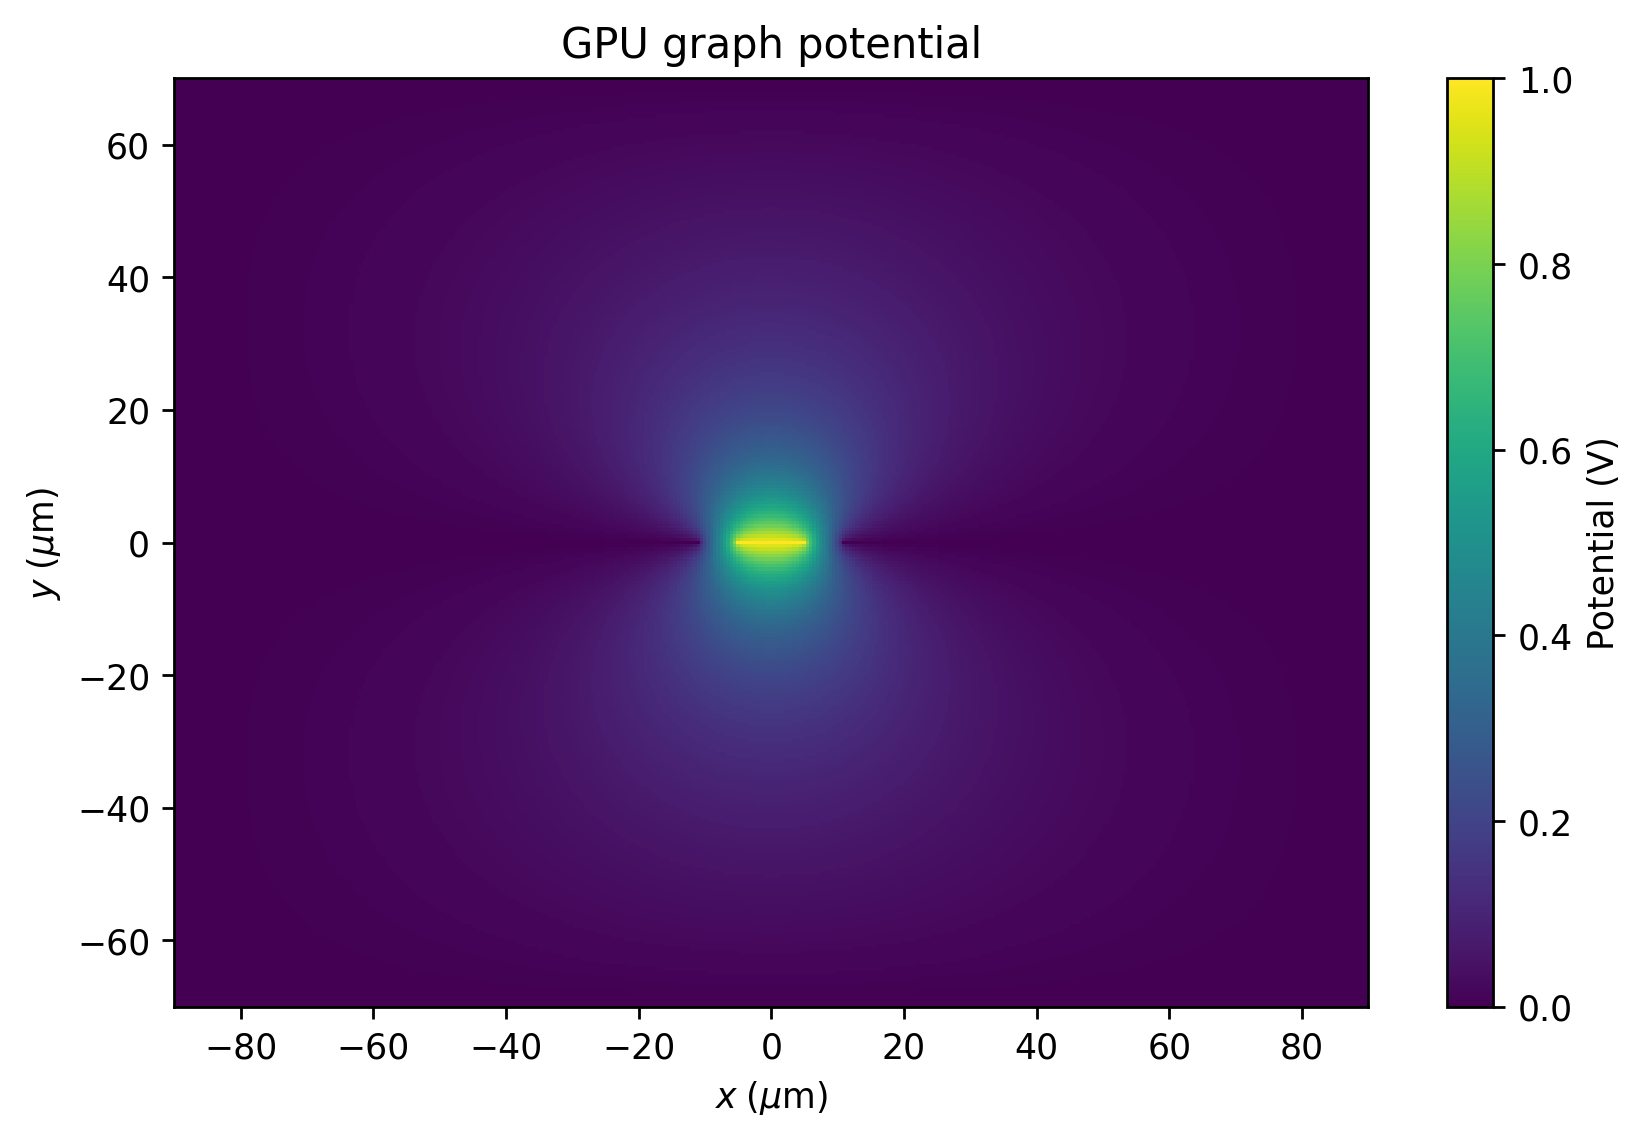

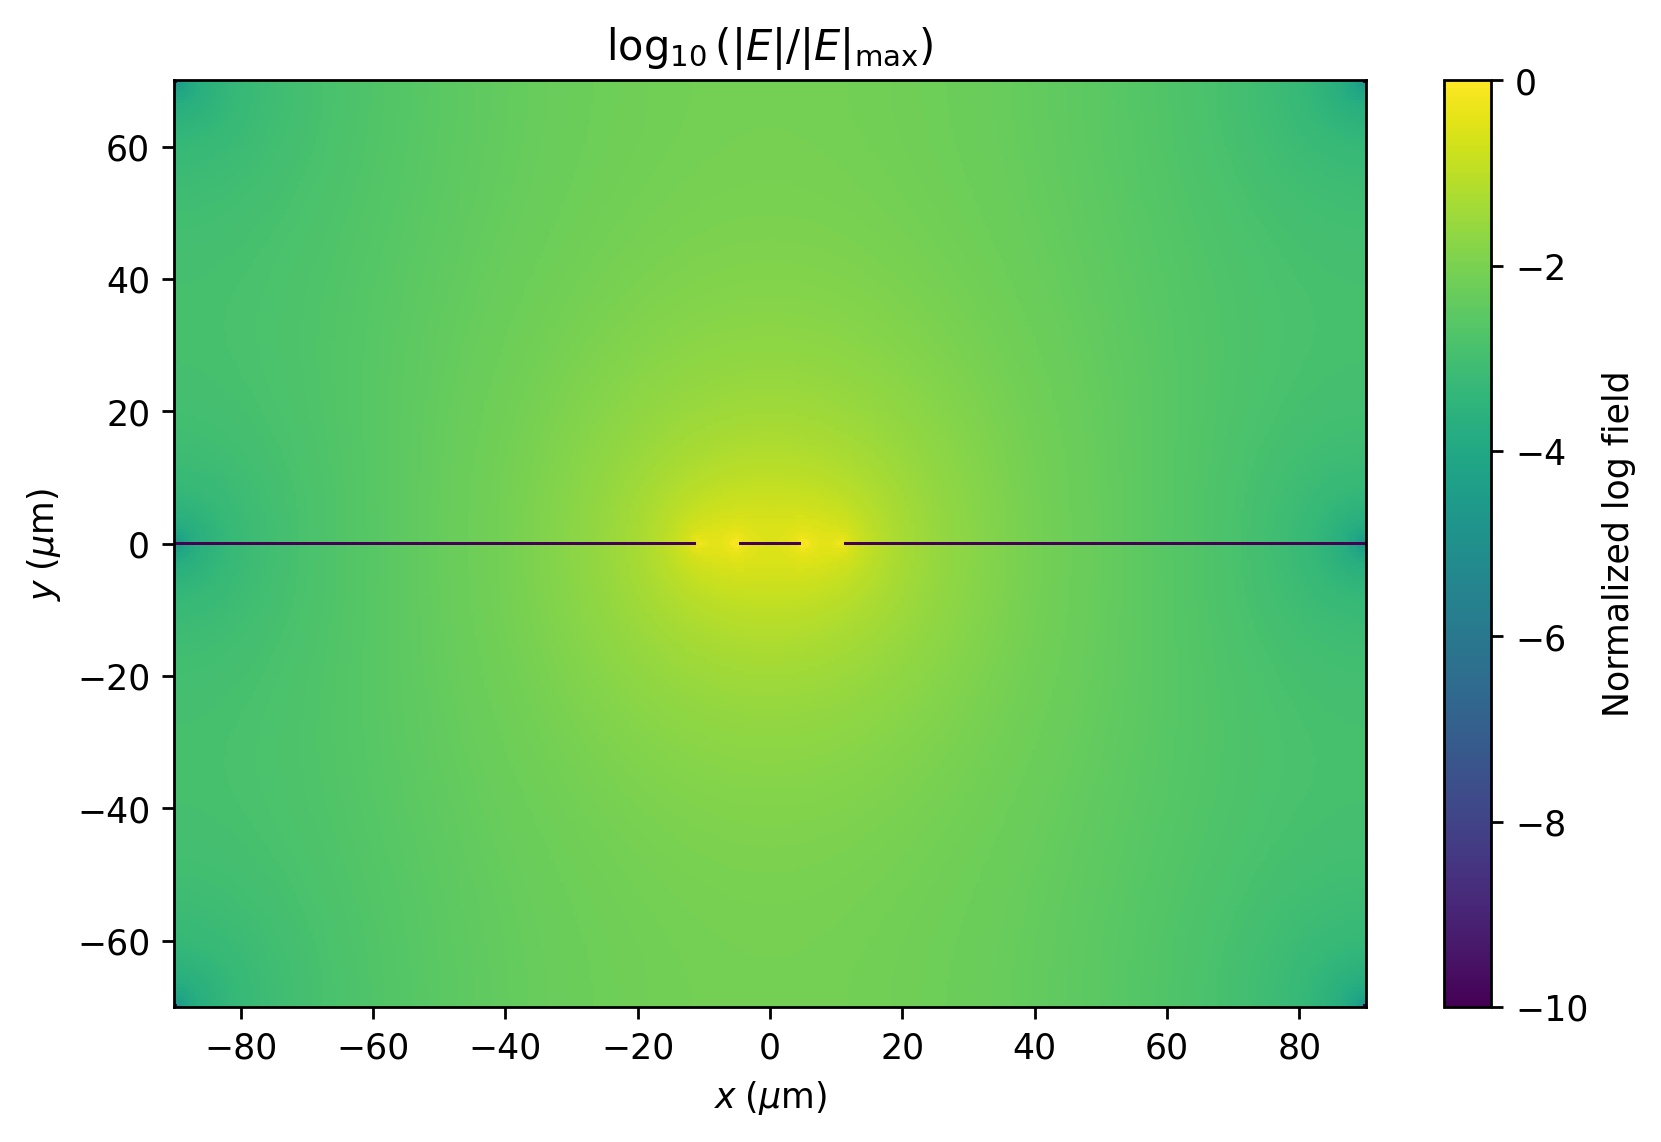

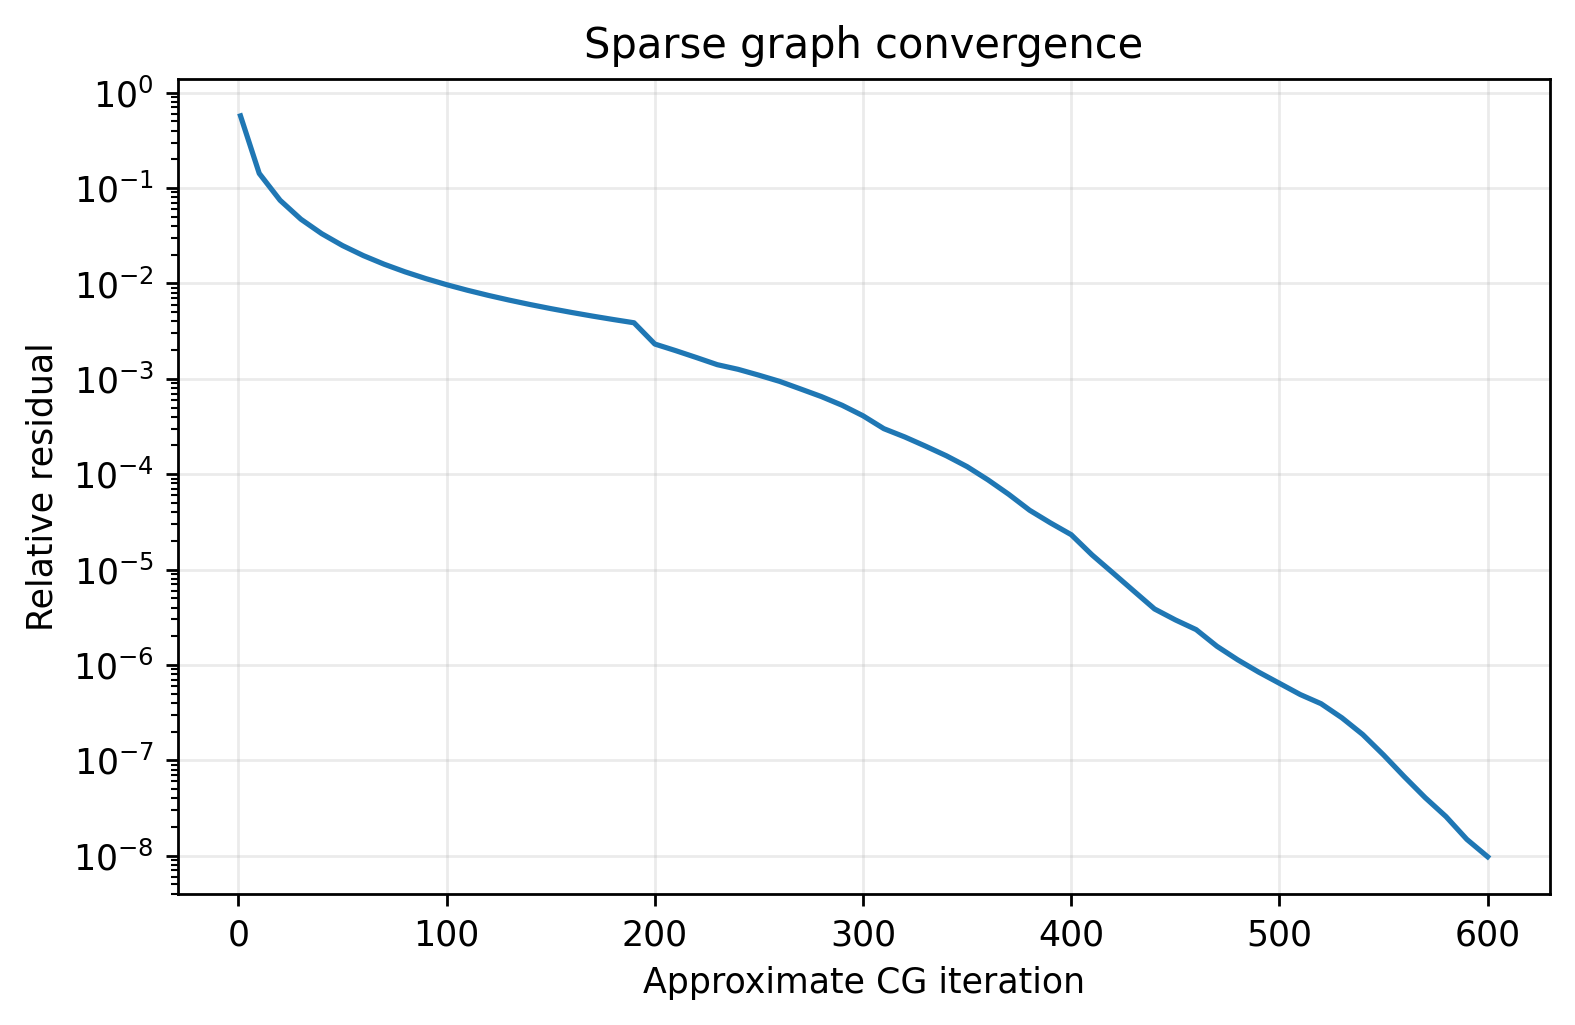


Building graph-derived gap surrogate...
Surrogate 1/7: gap=3.500 um, C0'=32.0505 pF/m, time=0.859 s
Surrogate 2/7: gap=4.417 um, C0'=29.6899 pF/m, time=1.480 s
Surrogate 3/7: gap=5.333 um, C0'=27.9446 pF/m, time=0.713 s
Surrogate 4/7: gap=6.250 um, C0'=26.5836 pF/m, time=0.310 s
Surrogate 5/7: gap=7.167 um, C0'=25.4832 pF/m, time=0.294 s
Surrogate 6/7: gap=8.083 um, C0'=24.5698 pF/m, time=0.304 s
Surrogate 7/7: gap=9.000 um, C0'=24.1677 pF/m, time=0.283 s


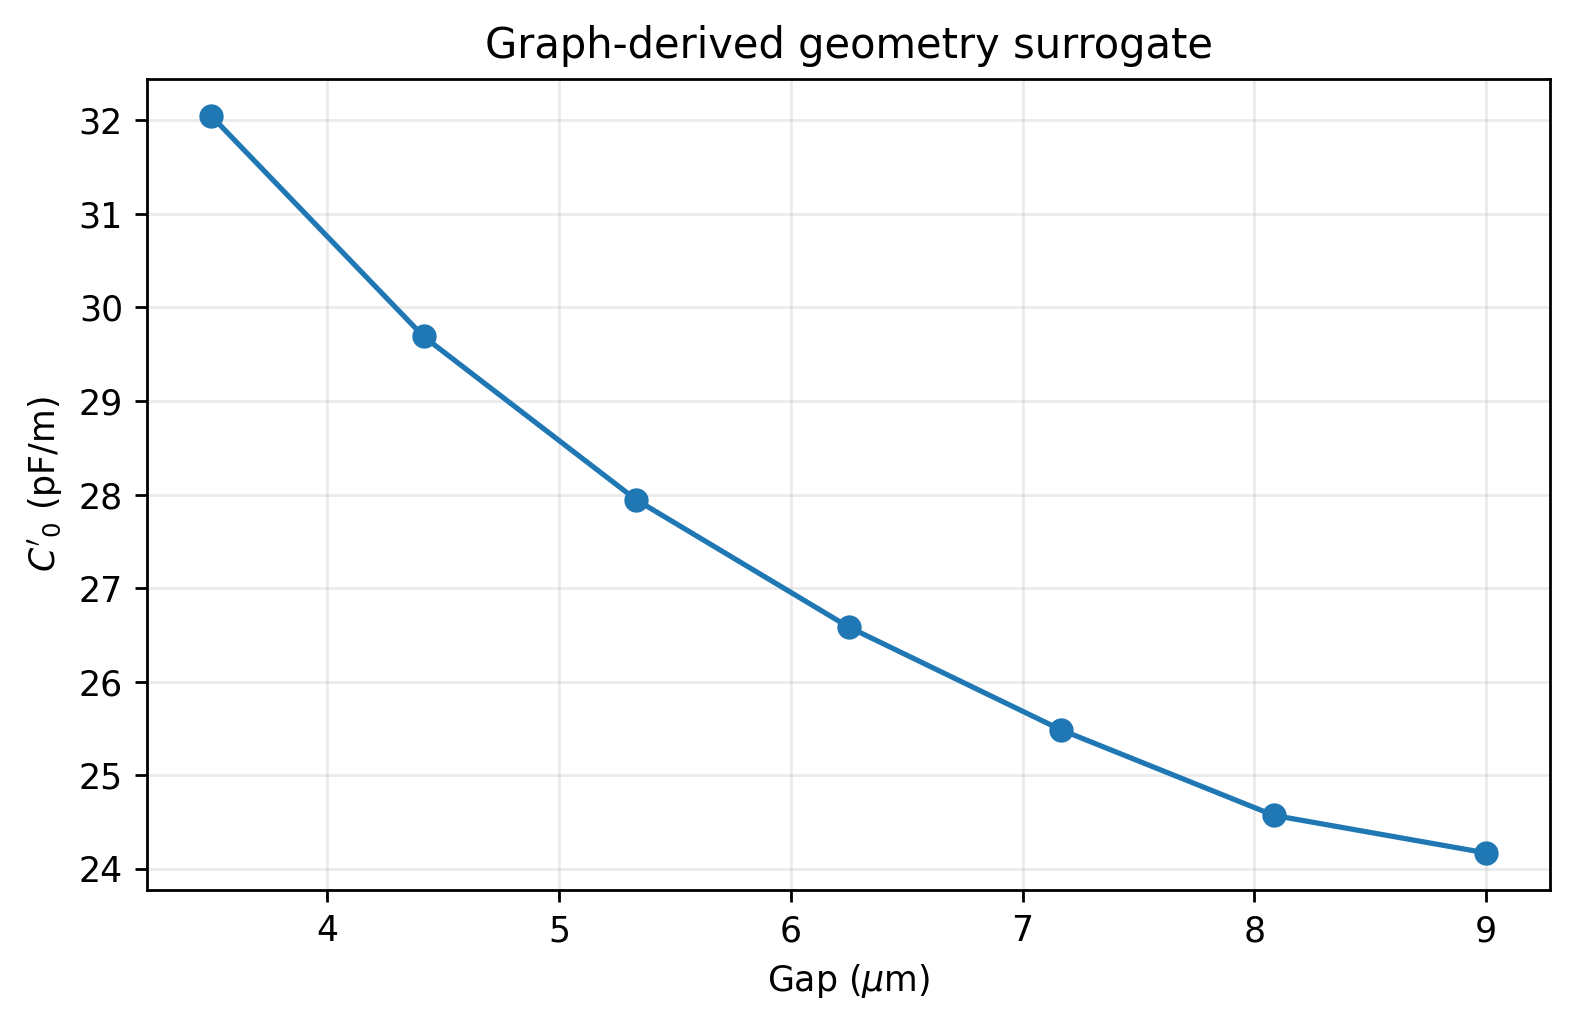


Calibration target
Source: conformal mapping
Z0: 55.693552 ohm
f0: 6.086467116 GHz

Running parallel GPU Metropolis-Hastings...
Acceptance rate: 24.10%
Posterior gap: 6.51432 um
95% gap interval: [6.36197, 6.67166] um
Posterior epsilon_r: 9.400052
95% epsilon_r interval: [9.380078, 9.420089]
MH wall time: 2.269 s


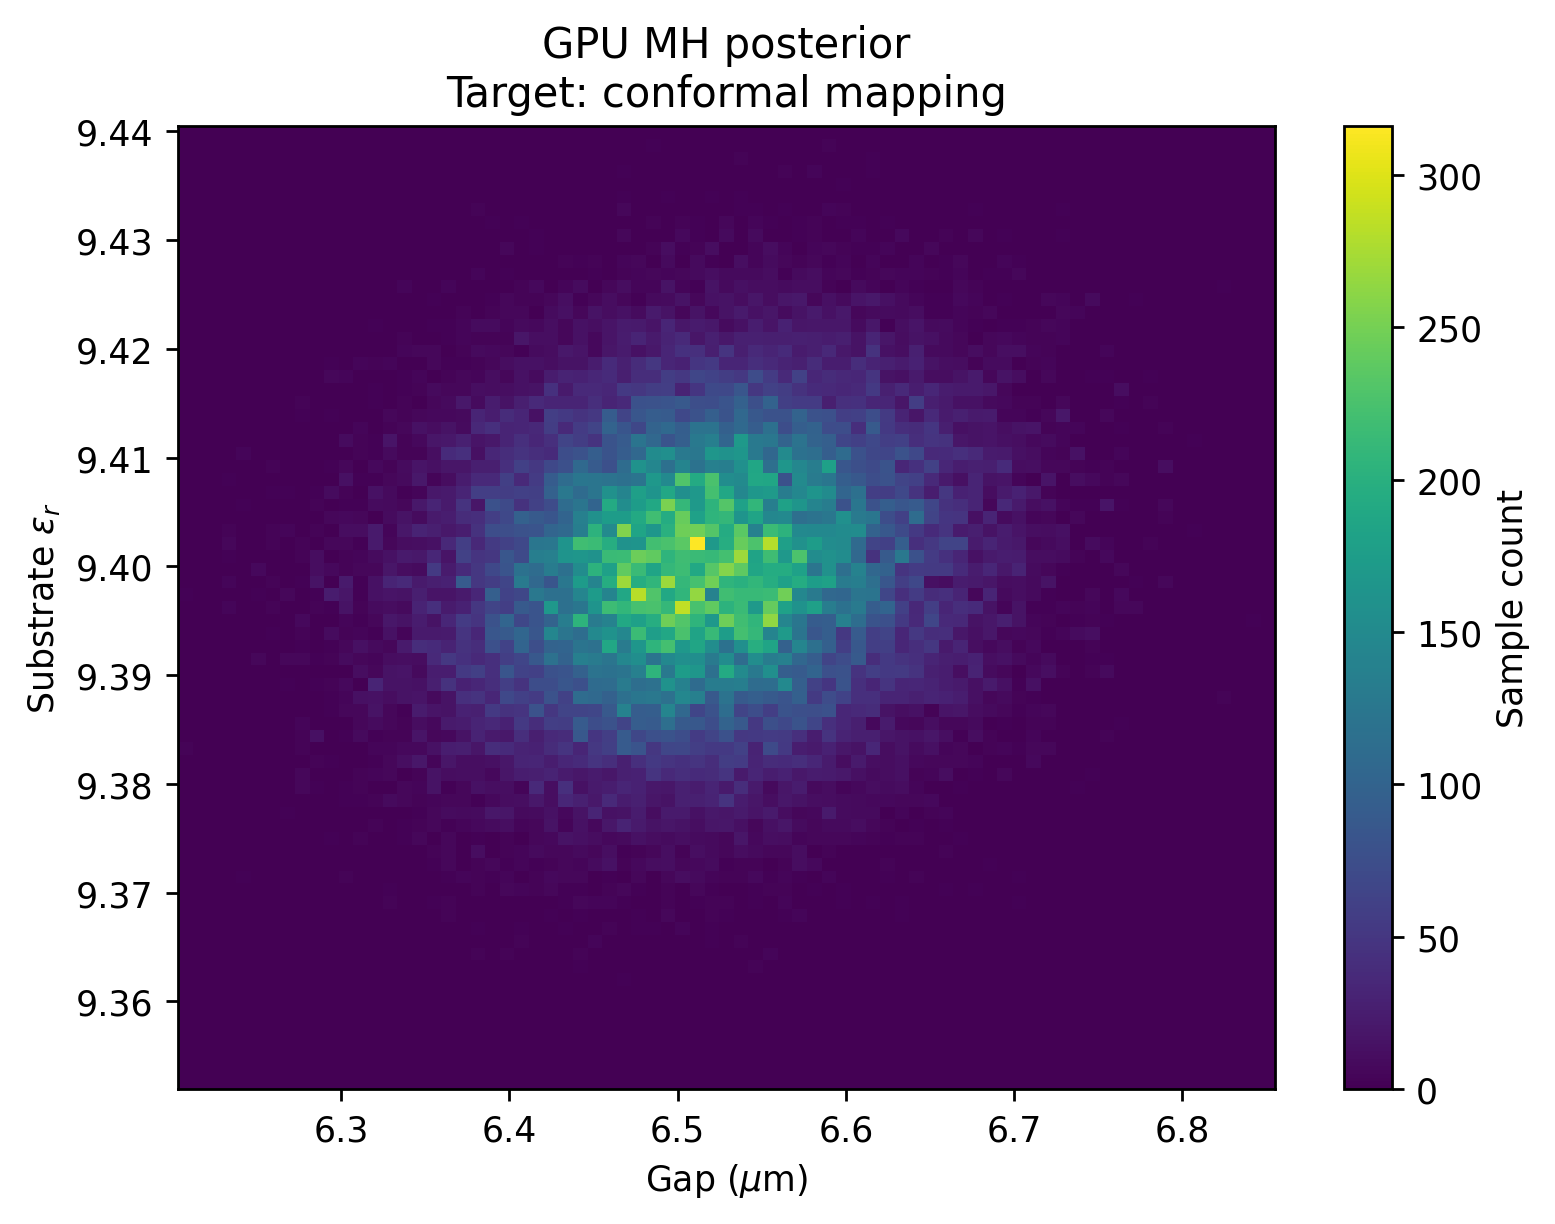

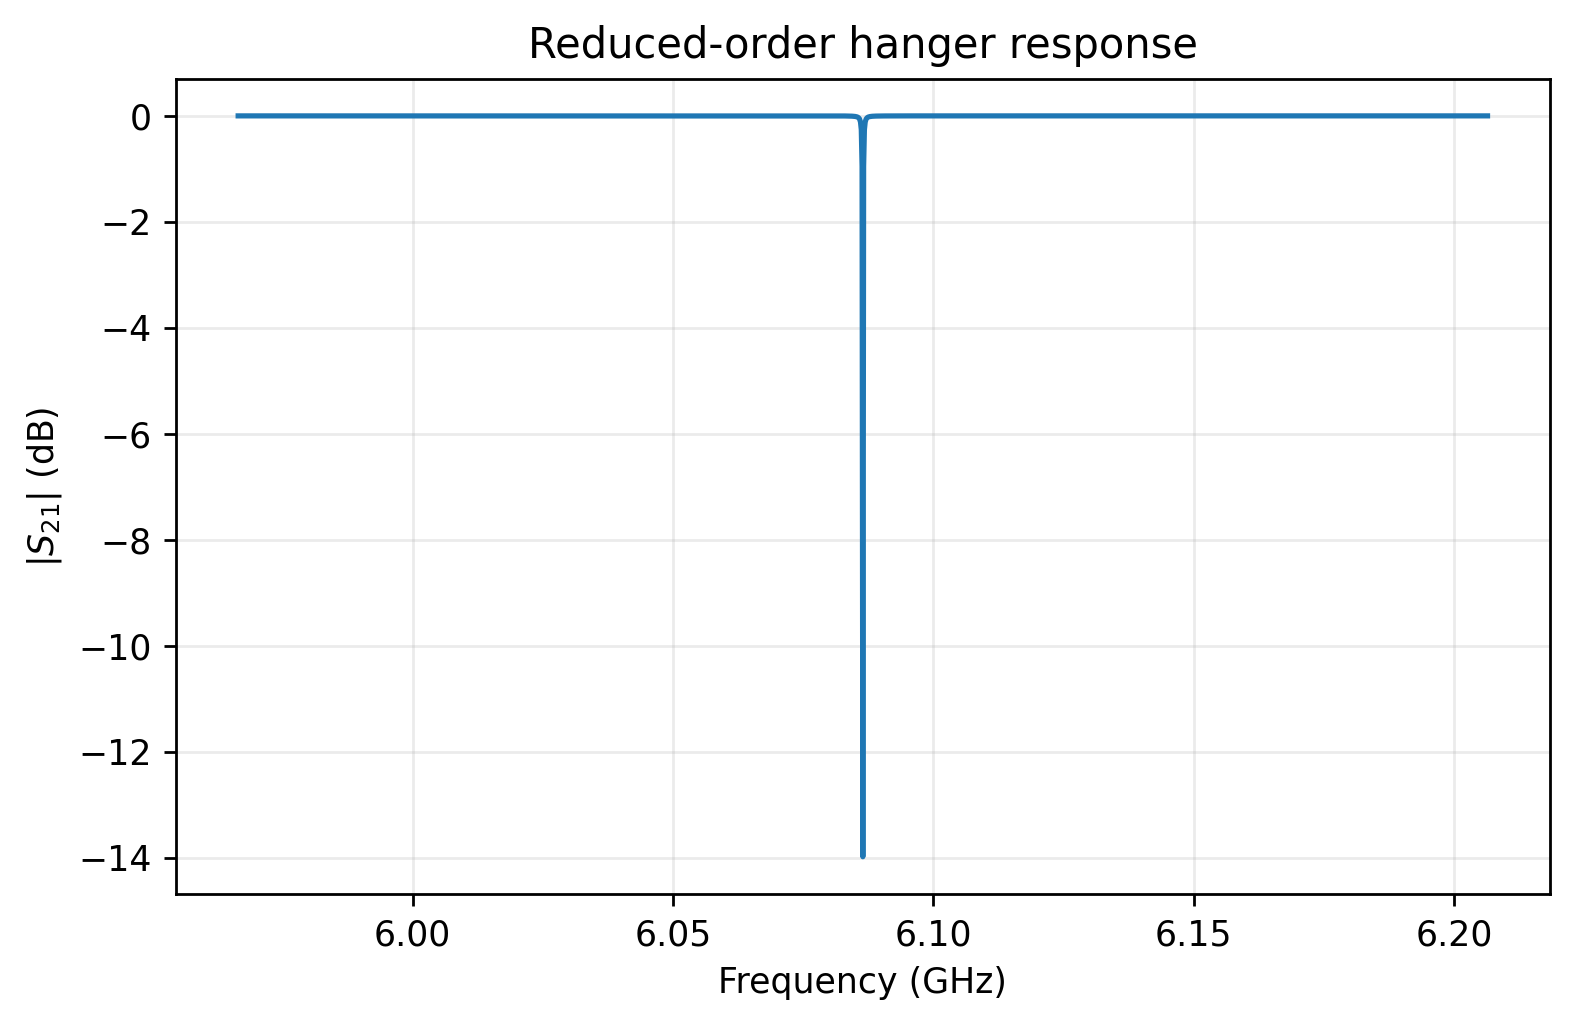


Saved files:
  /content/topotensor_cpw_outputs/cpw_benchmark_summary.csv
  /content/topotensor_cpw_outputs/cpw_graph_fields.npz
  /content/topotensor_cpw_outputs/graph_gap_surrogate.csv
  /content/topotensor_cpw_outputs/mh_posterior_samples.csv
  /content/topotensor_cpw_outputs/reduced_order_hanger_s21.csv


In [4]:
# @title GPU TopoTensor Metropolis-Hastings CPW Custom Solver

"""Solve a CPW using a GPU graph-tensor method with MH calibration.

The deterministic solver converts

    div(epsilon_r * grad(V)) = 0

into a weighted adjacency-graph Laplacian. CuPy stores and processes the
potential, electric field, material properties, graph weights, and sparse
linear system on the GPU.

Capacitance is independently extracted from electrostatic energy and center
conductor charge. Their agreement provides an internal numerical check.

A graph-derived geometry surrogate is subsequently constructed across CPW
gap values. Parallel Metropolis-Hastings chains use that surrogate to infer
geometry and material parameters from an independent target.

The present implementation is a quasi-TEM benchmark tier. It can later be
extended to vector FDFD, FEM, superconducting surface impedance, kinetic
inductance, and full S-parameter extraction.
"""

import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Final

import cupy as cp
import cupyx.scipy.sparse as cpx_sparse
import cupyx.scipy.sparse.linalg as cpx_linalg
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import ellipk


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

GPU_DEVICE_ID: Final[int] = 0
RANDOM_SEED: Final[int] = 17

CENTER_WIDTH_UM: Final[float] = 10.0
GAP_UM: Final[float] = 6.0
SUBSTRATE_EPS_R: Final[float] = 9.4

RESONATOR_LENGTH_UM: Final[float] = 5400.0

GRID_STEP_UM: Final[float] = 0.50

BOX_HALF_WIDTH_UM: Final[float] = 90.0
BOX_AIR_HEIGHT_UM: Final[float] = 70.0
BOX_SUBSTRATE_DEPTH_UM: Final[float] = 70.0

AUTO_EXPAND_BOX: Final[bool] = True
BOUNDARY_FIELD_TARGET: Final[float] = 0.010
BOX_EXPANSION_FACTOR: Final[float] = 1.35
MAX_BOX_EXPANSIONS: Final[int] = 2
MAX_GRID_POINTS: Final[int] = 800_000

USE_FLOAT64: Final[bool] = True

CG_TOL: Final[float] = 1.0e-8
CG_MAXITER: Final[int] = 4000
RESIDUAL_STRIDE: Final[int] = 10

ACTIVE_ENERGY_PERCENTILE: Final[float] = 95.0

RUN_MH: Final[bool] = True

SURROGATE_GAP_MIN_UM: Final[float] = 3.5
SURROGATE_GAP_MAX_UM: Final[float] = 9.0
SURROGATE_GAP_POINTS: Final[int] = 7

MH_CHAINS: Final[int] = 192
MH_STEPS: Final[int] = 1800
MH_BURN_IN: Final[int] = 600
MH_THIN: Final[int] = 2

MH_GAP_PROPOSAL_UM: Final[float] = 0.055
MH_EPS_PROPOSAL: Final[float] = 0.045

MH_EPS_MIN: Final[float] = 6.5
MH_EPS_MAX: Final[float] = 12.5

TARGET_SIGMA_Z0_OHM: Final[float] = 0.20
TARGET_SIGMA_F0_MHZ: Final[float] = 3.0

# Enter independently extracted ADS values here later.
ADS_TARGET_Z0_OHM: Final[float | None] = None
ADS_TARGET_F0_GHZ: Final[float | None] = None

PLOT_FIELDS: Final[bool] = True
PLOT_POSTERIOR: Final[bool] = True
PLOT_REDUCED_ORDER_S21: Final[bool] = True

Q_INTERNAL: Final[float] = 200_000.0
Q_COUPLING: Final[float] = 50_000.0

S21_SPAN_MHZ: Final[float] = 120.0
S21_POINTS: Final[int] = 1601

OUTPUT_DIR: Final[Path] = Path(
    "/content/topotensor_cpw_outputs"
)


# -----------------------------------------------------------------------------
# Physical constants
# -----------------------------------------------------------------------------

EPSILON_0: Final[float] = 8.854_187_812_8e-12
C_LIGHT: Final[float] = 299_792_458.0


# -----------------------------------------------------------------------------
# Result containers
# -----------------------------------------------------------------------------

@dataclass
class GraphSolution:
    """Store one electrostatic graph solution."""

    x_um: cp.ndarray
    y_um: cp.ndarray
    potential_v: cp.ndarray
    e_mag_v_m: cp.ndarray
    energy_density_j_m3: cp.ndarray

    capacitance_energy_f_m: float
    capacitance_charge_f_m: float
    capacitance_mismatch: float

    boundary_field_ratio: float
    active_node_fraction: float
    active_energy_fraction: float

    unknown_nodes: int
    graph_nnz: int

    cg_info: int
    relative_residual: float
    residual_history: list[float]

    solve_time_s: float

    half_width_um: float
    air_height_um: float
    substrate_depth_um: float


@dataclass
class MhResult:
    """Store Metropolis-Hastings posterior results."""

    gap_samples_um: np.ndarray
    eps_samples: np.ndarray

    acceptance_rate: float

    gap_median_um: float
    gap_ci95_um: tuple[float, float]

    eps_median: float
    eps_ci95: tuple[float, float]


# -----------------------------------------------------------------------------
# GPU setup
# -----------------------------------------------------------------------------

def select_gpu() -> None:
    """Select the requested CUDA GPU and print its properties."""

    cp.cuda.Device(GPU_DEVICE_ID).use()

    properties = cp.cuda.runtime.getDeviceProperties(
        GPU_DEVICE_ID
    )

    gpu_name = properties["name"]

    if isinstance(gpu_name, bytes):
        gpu_name = gpu_name.decode()

    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()

    print(f"GPU: {gpu_name}")
    print(f"CuPy: {cp.__version__}")
    print(
        "CUDA runtime: "
        f"{cp.cuda.runtime.runtimeGetVersion()}"
    )
    print(
        "GPU memory: "
        f"{free_bytes / 2**30:.2f} / "
        f"{total_bytes / 2**30:.2f} GiB free"
    )


def gpu_dtype():
    """Return the requested CuPy floating-point precision."""

    if USE_FLOAT64:
        return cp.float64

    return cp.float32


# -----------------------------------------------------------------------------
# Grid construction
# -----------------------------------------------------------------------------

def grid_shape(
    half_width_um: float,
    air_height_um: float,
    substrate_depth_um: float,
) -> tuple[int, int]:
    """Return the x and y grid dimensions."""

    nx_half = int(
        math.ceil(half_width_um / GRID_STEP_UM)
    )
    ny_air = int(
        math.ceil(air_height_um / GRID_STEP_UM)
    )
    ny_sub = int(
        math.ceil(substrate_depth_um / GRID_STEP_UM)
    )

    nx = 2 * nx_half + 1
    ny = ny_sub + ny_air + 1

    return nx, ny


def build_grid(
    half_width_um: float,
    air_height_um: float,
    substrate_depth_um: float,
):
    """Create GPU coordinates with the CPW plane at y = 0."""

    dtype = gpu_dtype()

    nx_half = int(
        math.ceil(half_width_um / GRID_STEP_UM)
    )
    ny_air = int(
        math.ceil(air_height_um / GRID_STEP_UM)
    )
    ny_sub = int(
        math.ceil(substrate_depth_um / GRID_STEP_UM)
    )

    x_um = (
        cp.arange(
            -nx_half,
            nx_half + 1,
            dtype=dtype,
        )
        * GRID_STEP_UM
    )

    y_um = (
        cp.arange(
            -ny_sub,
            ny_air + 1,
            dtype=dtype,
        )
        * GRID_STEP_UM
    )

    return x_um, y_um, ny_sub


# -----------------------------------------------------------------------------
# Sparse adjacency graph
# -----------------------------------------------------------------------------

def add_edge_family(
    unknown_a: cp.ndarray,
    unknown_b: cp.ndarray,
    index_a: cp.ndarray,
    index_b: cp.ndarray,
    fixed_value_a: cp.ndarray,
    fixed_value_b: cp.ndarray,
    conductance: cp.ndarray,
    diagonal: cp.ndarray,
    rhs: cp.ndarray,
    off_rows: list[cp.ndarray],
    off_cols: list[cp.ndarray],
    off_data: list[cp.ndarray],
) -> None:
    """Add one family of weighted graph edges."""

    n_unknown = diagonal.size

    both_unknown = unknown_a & unknown_b

    p = index_a[both_unknown]
    q = index_b[both_unknown]
    weight = conductance[both_unknown]

    off_rows.append(
        cp.concatenate((p, q))
    )
    off_cols.append(
        cp.concatenate((q, p))
    )
    off_data.append(
        cp.concatenate((-weight, -weight))
    )

    diagonal += cp.bincount(
        p,
        weights=weight,
        minlength=n_unknown,
    )

    diagonal += cp.bincount(
        q,
        weights=weight,
        minlength=n_unknown,
    )

    a_unknown = unknown_a & ~unknown_b

    p = index_a[a_unknown]
    weight = conductance[a_unknown]

    diagonal += cp.bincount(
        p,
        weights=weight,
        minlength=n_unknown,
    )

    rhs += cp.bincount(
        p,
        weights=(
            weight
            * fixed_value_b[a_unknown]
        ),
        minlength=n_unknown,
    )

    b_unknown = ~unknown_a & unknown_b

    q = index_b[b_unknown]
    weight = conductance[b_unknown]

    diagonal += cp.bincount(
        q,
        weights=weight,
        minlength=n_unknown,
    )

    rhs += cp.bincount(
        q,
        weights=(
            weight
            * fixed_value_a[b_unknown]
        ),
        minlength=n_unknown,
    )


class ResidualRecorder:
    """Record CG residuals at a reduced sampling rate."""

    def __init__(
        self,
        matrix,
        rhs: cp.ndarray,
    ) -> None:
        self.matrix = matrix
        self.rhs = rhs

        self.iteration = 0
        self.values: list[float] = []

        self.rhs_norm = cp.maximum(
            cp.linalg.norm(rhs),
            cp.asarray(
                1.0e-30,
                dtype=rhs.dtype,
            ),
        )

    def __call__(
        self,
        x_k: cp.ndarray,
    ) -> None:
        self.iteration += 1

        should_record = (
            self.iteration == 1
            or self.iteration
            % RESIDUAL_STRIDE
            == 0
        )

        if not should_record:
            return

        residual = (
            self.rhs
            - self.matrix @ x_k
        )

        value = (
            cp.linalg.norm(residual)
            / self.rhs_norm
        )

        self.values.append(
            float(value.get())
        )


def solve_cg(
    matrix,
    rhs: cp.ndarray,
):
    """Solve the graph Laplacian with Jacobi-preconditioned CG."""

    inverse_diagonal = (
        1.0 / matrix.diagonal()
    )

    preconditioner = cpx_sparse.diags(
        inverse_diagonal,
        format="csr",
    )

    recorder = ResidualRecorder(
        matrix,
        rhs,
    )

    common_arguments = {
        "maxiter": CG_MAXITER,
        "M": preconditioner,
        "callback": recorder,
    }

    try:
        solution, info = cpx_linalg.cg(
            matrix,
            rhs,
            tol=CG_TOL,
            atol=0.0,
            **common_arguments,
        )
    except TypeError:
        solution, info = cpx_linalg.cg(
            matrix,
            rhs,
            rtol=CG_TOL,
            atol=0.0,
            **common_arguments,
        )

    rhs_norm = cp.maximum(
        cp.linalg.norm(rhs),
        cp.asarray(
            1.0e-30,
            dtype=rhs.dtype,
        ),
    )

    final_residual = (
        cp.linalg.norm(
            rhs - matrix @ solution
        )
        / rhs_norm
    )

    final_value = float(
        final_residual.get()
    )

    recorder.values.append(
        final_value
    )

    return (
        solution,
        int(info),
        recorder.values,
        final_value,
    )


# -----------------------------------------------------------------------------
# Graph-tensor electrostatic solver
# -----------------------------------------------------------------------------

def solve_cpw_graph(
    substrate_eps_r: float,
    gap_um: float,
    half_width_um: float,
    air_height_um: float,
    substrate_depth_um: float,
) -> GraphSolution:
    """Solve the CPW cross section using a weighted GPU graph."""

    start_time = time.perf_counter()

    dtype = gpu_dtype()

    nx, ny = grid_shape(
        half_width_um,
        air_height_um,
        substrate_depth_um,
    )

    point_count = nx * ny

    if point_count > MAX_GRID_POINTS:
        raise RuntimeError(
            "Grid contains "
            f"{point_count:,} points. "
            "Increase MAX_GRID_POINTS or "
            "coarsen GRID_STEP_UM."
        )

    x_um, y_um, surface_index = build_grid(
        half_width_um,
        air_height_um,
        substrate_depth_um,
    )

    nx = int(x_um.size)
    ny = int(y_um.size)

    dx_m = GRID_STEP_UM * 1.0e-6
    dy_m = dx_m

    fixed_mask = cp.zeros(
        (ny, nx),
        dtype=cp.bool_,
    )

    fixed_value = cp.zeros(
        (ny, nx),
        dtype=dtype,
    )

    fixed_mask[0, :] = True
    fixed_mask[-1, :] = True
    fixed_mask[:, 0] = True
    fixed_mask[:, -1] = True

    half_center_um = (
        CENTER_WIDTH_UM / 2.0
    )

    ground_start_um = (
        half_center_um + gap_um
    )

    center_x = (
        cp.abs(x_um)
        <= half_center_um + 1.0e-12
    )

    ground_x = (
        cp.abs(x_um)
        >= ground_start_um - 1.0e-12
    )

    metal_x = center_x | ground_x

    fixed_mask[
        surface_index,
        metal_x,
    ] = True

    fixed_value[
        surface_index,
        center_x,
    ] = 1.0

    center_mask = cp.zeros(
        (ny, nx),
        dtype=cp.bool_,
    )

    center_mask[
        surface_index,
        center_x,
    ] = True

    unknown = ~fixed_mask

    n_unknown = int(
        cp.count_nonzero(
            unknown
        ).get()
    )

    index_map = cp.full(
        (ny, nx),
        -1,
        dtype=cp.int64,
    )

    index_map[unknown] = cp.arange(
        n_unknown,
        dtype=cp.int64,
    )

    diagonal = cp.zeros(
        n_unknown,
        dtype=dtype,
    )

    rhs = cp.zeros(
        n_unknown,
        dtype=dtype,
    )

    off_rows: list[cp.ndarray] = []
    off_cols: list[cp.ndarray] = []
    off_data: list[cp.ndarray] = []

    interface_eps_r = (
        0.5
        * (1.0 + substrate_eps_r)
    )

    horizontal_eps = cp.where(
        y_um < 0.0,
        substrate_eps_r,
        cp.where(
            y_um > 0.0,
            1.0,
            interface_eps_r,
        ),
    ).astype(dtype)

    g_horizontal = cp.broadcast_to(
        horizontal_eps[:, None],
        (ny, nx - 1),
    ).ravel()

    g_horizontal *= (
        dy_m / dx_m
    )

    y_mid_um = (
        0.5
        * (
            y_um[:-1]
            + y_um[1:]
        )
    )

    vertical_eps = cp.where(
        y_mid_um < 0.0,
        substrate_eps_r,
        1.0,
    ).astype(dtype)

    g_vertical = cp.broadcast_to(
        vertical_eps[:, None],
        (ny - 1, nx),
    ).ravel()

    g_vertical *= (
        dx_m / dy_m
    )

    add_edge_family(
        unknown[:, :-1].ravel(),
        unknown[:, 1:].ravel(),
        index_map[:, :-1].ravel(),
        index_map[:, 1:].ravel(),
        fixed_value[:, :-1].ravel(),
        fixed_value[:, 1:].ravel(),
        g_horizontal,
        diagonal,
        rhs,
        off_rows,
        off_cols,
        off_data,
    )

    add_edge_family(
        unknown[:-1, :].ravel(),
        unknown[1:, :].ravel(),
        index_map[:-1, :].ravel(),
        index_map[1:, :].ravel(),
        fixed_value[:-1, :].ravel(),
        fixed_value[1:, :].ravel(),
        g_vertical,
        diagonal,
        rhs,
        off_rows,
        off_cols,
        off_data,
    )

    diagonal_index = cp.arange(
        n_unknown,
        dtype=cp.int64,
    )

    rows = cp.concatenate(
        off_rows
        + [diagonal_index]
    )

    columns = cp.concatenate(
        off_cols
        + [diagonal_index]
    )

    data = cp.concatenate(
        off_data
        + [diagonal]
    )

    matrix = cpx_sparse.coo_matrix(
        (
            data,
            (rows, columns),
        ),
        shape=(
            n_unknown,
            n_unknown,
        ),
        dtype=dtype,
    ).tocsr()

    (
        solution,
        cg_info,
        residual_history,
        relative_residual,
    ) = solve_cg(
        matrix,
        rhs,
    )

    potential = fixed_value.copy()

    potential[unknown] = solution

    g_h = g_horizontal.reshape(
        ny,
        nx - 1,
    )

    g_v = g_vertical.reshape(
        ny - 1,
        nx,
    )

    delta_h = (
        potential[:, :-1]
        - potential[:, 1:]
    )

    delta_v = (
        potential[:-1, :]
        - potential[1:, :]
    )

    graph_energy_twice = (
        EPSILON_0
        * (
            cp.sum(
                g_h * delta_h**2
            )
            + cp.sum(
                g_v * delta_v**2
            )
        )
    )

    capacitance_energy = float(
        graph_energy_twice.get()
    )

    center_h = (
        center_mask[:, :-1]
        ^ center_mask[:, 1:]
    )

    center_v = (
        center_mask[:-1, :]
        ^ center_mask[1:, :]
    )

    charge_relative = (
        cp.sum(
            g_h[center_h]
            * cp.abs(
                delta_h[center_h]
            )
        )
        + cp.sum(
            g_v[center_v]
            * cp.abs(
                delta_v[center_v]
            )
        )
    )

    capacitance_charge = float(
        (
            EPSILON_0
            * charge_relative
        ).get()
    )

    capacitance_mismatch = (
        abs(
            capacitance_energy
            - capacitance_charge
        )
        / max(
            capacitance_charge,
            1.0e-30,
        )
    )

    grad_y, grad_x = cp.gradient(
        potential,
        dy_m,
        dx_m,
    )

    e_x = -grad_x
    e_y = -grad_y

    e_mag = cp.sqrt(
        e_x**2 + e_y**2
    )

    node_eps = cp.where(
        y_um < 0.0,
        substrate_eps_r,
        cp.where(
            y_um > 0.0,
            1.0,
            interface_eps_r,
        ),
    ).astype(dtype)

    node_eps = cp.broadcast_to(
        node_eps[:, None],
        (ny, nx),
    )

    energy_density = (
        0.5
        * EPSILON_0
        * node_eps
        * (
            e_x**2
            + e_y**2
        )
    )

    boundary_field = cp.concatenate(
        (
            e_mag[1, :],
            e_mag[-2, :],
            e_mag[:, 1],
            e_mag[:, -2],
        )
    )

    boundary_field_ratio = float(
        (
            cp.max(boundary_field)
            / cp.maximum(
                cp.max(e_mag),
                cp.asarray(
                    1.0e-30,
                    dtype=dtype,
                ),
            )
        ).get()
    )

    energy_threshold = cp.percentile(
        energy_density,
        ACTIVE_ENERGY_PERCENTILE,
    )

    active_mask = (
        energy_density
        >= energy_threshold
    )

    active_node_fraction = float(
        cp.mean(
            active_mask
        ).get()
    )

    active_energy_fraction = float(
        (
            cp.sum(
                energy_density[
                    active_mask
                ]
            )
            / cp.maximum(
                cp.sum(
                    energy_density
                ),
                cp.asarray(
                    1.0e-30,
                    dtype=dtype,
                ),
            )
        ).get()
    )

    elapsed_s = (
        time.perf_counter()
        - start_time
    )

    return GraphSolution(
        x_um=x_um,
        y_um=y_um,
        potential_v=potential,
        e_mag_v_m=e_mag,
        energy_density_j_m3=energy_density,
        capacitance_energy_f_m=(
            capacitance_energy
        ),
        capacitance_charge_f_m=(
            capacitance_charge
        ),
        capacitance_mismatch=(
            capacitance_mismatch
        ),
        boundary_field_ratio=(
            boundary_field_ratio
        ),
        active_node_fraction=(
            active_node_fraction
        ),
        active_energy_fraction=(
            active_energy_fraction
        ),
        unknown_nodes=n_unknown,
        graph_nnz=int(matrix.nnz),
        cg_info=cg_info,
        relative_residual=(
            relative_residual
        ),
        residual_history=(
            residual_history
        ),
        solve_time_s=elapsed_s,
        half_width_um=float(
            cp.max(
                cp.abs(x_um)
            ).get()
        ),
        air_height_um=float(
            cp.max(y_um).get()
        ),
        substrate_depth_um=float(
            -cp.min(y_um).get()
        ),
    )


# -----------------------------------------------------------------------------
# Adaptive computational domain
# -----------------------------------------------------------------------------

def solve_nominal_adaptive():
    """Expand the computational box if its boundary field is too large."""

    half_width = BOX_HALF_WIDTH_UM
    air_height = BOX_AIR_HEIGHT_UM
    substrate_depth = (
        BOX_SUBSTRATE_DEPTH_UM
    )

    history = []
    final_solution = None

    for pass_index in range(
        MAX_BOX_EXPANSIONS + 1
    ):
        nx, ny = grid_shape(
            half_width,
            air_height,
            substrate_depth,
        )

        if nx * ny > MAX_GRID_POINTS:
            if final_solution is None:
                raise RuntimeError(
                    "Initial grid exceeds "
                    "MAX_GRID_POINTS."
                )

            print(
                "Further box expansion "
                "would exceed MAX_GRID_POINTS."
            )
            break

        final_solution = solve_cpw_graph(
            substrate_eps_r=(
                SUBSTRATE_EPS_R
            ),
            gap_um=GAP_UM,
            half_width_um=half_width,
            air_height_um=air_height,
            substrate_depth_um=(
                substrate_depth
            ),
        )

        history.append(
            {
                "pass": pass_index,
                "unknown_nodes": (
                    final_solution
                    .unknown_nodes
                ),
                "boundary_ratio": (
                    final_solution
                    .boundary_field_ratio
                ),
                "solve_time_s": (
                    final_solution
                    .solve_time_s
                ),
            }
        )

        print(
            f"Box pass {pass_index}: "
            f"{final_solution.unknown_nodes:,} "
            "unknown nodes, "
            "boundary field = "
            f"{100.0 * final_solution.boundary_field_ratio:.3f}%, "
            "solve time = "
            f"{final_solution.solve_time_s:.3f} s"
        )

        if not AUTO_EXPAND_BOX:
            break

        if (
            final_solution
            .boundary_field_ratio
            <= BOUNDARY_FIELD_TARGET
        ):
            break

        half_width *= (
            BOX_EXPANSION_FACTOR
        )

        air_height *= (
            BOX_EXPANSION_FACTOR
        )

        substrate_depth *= (
            BOX_EXPANSION_FACTOR
        )

    return final_solution, history


# -----------------------------------------------------------------------------
# Analytical reference
# -----------------------------------------------------------------------------

def analytic_cpw(
    width_um: float,
    gap_um: float,
    eps_r: float,
):
    """Return infinite-substrate conformal-mapping CPW quantities."""

    k = (
        width_um
        / (
            width_um
            + 2.0 * gap_um
        )
    )

    m = k**2

    complete_k = ellipk(m)
    complete_k_prime = ellipk(
        1.0 - m
    )

    vacuum_capacitance = (
        4.0
        * EPSILON_0
        * complete_k
        / complete_k_prime
    )

    eps_eff = (
        0.5
        * (1.0 + eps_r)
    )

    capacitance = (
        vacuum_capacitance
        * eps_eff
    )

    z0 = (
        1.0
        / (
            C_LIGHT
            * math.sqrt(
                vacuum_capacitance
                * capacitance
            )
        )
    )

    return {
        "c0_f_m": vacuum_capacitance,
        "c_f_m": capacitance,
        "eps_eff": eps_eff,
        "z0_ohm": z0,
    }


def line_metrics(
    capacitance_f_m: float,
    vacuum_capacitance_f_m: float,
):
    """Calculate quasi-TEM line and quarter-wave resonator quantities."""

    eps_eff = (
        capacitance_f_m
        / vacuum_capacitance_f_m
    )

    phase_velocity = (
        C_LIGHT
        / math.sqrt(eps_eff)
    )

    z0 = (
        1.0
        / (
            C_LIGHT
            * math.sqrt(
                capacitance_f_m
                * vacuum_capacitance_f_m
            )
        )
    )

    resonator_length_m = (
        RESONATOR_LENGTH_UM
        * 1.0e-6
    )

    f0_hz = (
        phase_velocity
        / (
            4.0
            * resonator_length_m
        )
    )

    return {
        "eps_eff": eps_eff,
        "phase_velocity_m_s": (
            phase_velocity
        ),
        "z0_ohm": z0,
        "f0_hz": f0_hz,
    }


# -----------------------------------------------------------------------------
# Gap surrogate
# -----------------------------------------------------------------------------

def build_gap_surrogate(
    nominal: GraphSolution,
    nominal_vacuum: GraphSolution,
):
    """Build a graph-derived C0 versus gap surrogate."""

    gap_grid = np.linspace(
        SURROGATE_GAP_MIN_UM,
        SURROGATE_GAP_MAX_UM,
        SURROGATE_GAP_POINTS,
    )

    c0_grid = np.empty_like(
        gap_grid
    )

    for index, gap_um in enumerate(
        gap_grid
    ):
        if (
            abs(gap_um - GAP_UM)
            <= 0.25 * GRID_STEP_UM
        ):
            c0_grid[index] = (
                nominal_vacuum
                .capacitance_charge_f_m
            )

            print(
                f"Surrogate "
                f"{index + 1}/"
                f"{len(gap_grid)}: "
                f"gap={gap_um:.3f} um, "
                "reused nominal solution"
            )
            continue

        result = solve_cpw_graph(
            substrate_eps_r=1.0,
            gap_um=float(gap_um),
            half_width_um=(
                nominal.half_width_um
            ),
            air_height_um=(
                nominal.air_height_um
            ),
            substrate_depth_um=(
                nominal
                .substrate_depth_um
            ),
        )

        c0_grid[index] = (
            result
            .capacitance_charge_f_m
        )

        print(
            f"Surrogate "
            f"{index + 1}/"
            f"{len(gap_grid)}: "
            f"gap={gap_um:.3f} um, "
            f"C0'="
            f"{1.0e12 * c0_grid[index]:.4f} pF/m, "
            f"time={result.solve_time_s:.3f} s"
        )

    return gap_grid, c0_grid


# -----------------------------------------------------------------------------
# GPU interpolation
# -----------------------------------------------------------------------------

def gpu_linear_interp(
    x: cp.ndarray,
    xp: cp.ndarray,
    fp: cp.ndarray,
):
    """Perform one-dimensional linear interpolation on the GPU."""

    index = (
        cp.searchsorted(
            xp,
            x,
            side="right",
        )
        - 1
    )

    index = cp.clip(
        index,
        0,
        xp.size - 2,
    )

    x0 = xp[index]
    x1 = xp[index + 1]

    f0 = fp[index]
    f1 = fp[index + 1]

    fraction = (
        (x - x0)
        / (x1 - x0)
    )

    return (
        f0
        + fraction
        * (f1 - f0)
    )


# -----------------------------------------------------------------------------
# Fast graph-derived forward model
# -----------------------------------------------------------------------------

def surrogate_model(
    gap_um: cp.ndarray,
    eps_r: cp.ndarray,
    gap_grid: cp.ndarray,
    c0_grid: cp.ndarray,
):
    """Predict Z0 and f0 from the graph-derived geometry surrogate."""

    c0_per_m = gpu_linear_interp(
        gap_um,
        gap_grid,
        c0_grid,
    )

    eps_eff = (
        0.5
        * (1.0 + eps_r)
    )

    capacitance = (
        c0_per_m
        * eps_eff
    )

    z0 = (
        1.0
        / (
            C_LIGHT
            * cp.sqrt(
                c0_per_m
                * capacitance
            )
        )
    )

    length_m = (
        RESONATOR_LENGTH_UM
        * 1.0e-6
    )

    f0_hz = (
        C_LIGHT
        / (
            4.0
            * length_m
            * cp.sqrt(eps_eff)
        )
    )

    return z0, f0_hz


def log_posterior(
    gap_um: cp.ndarray,
    eps_r: cp.ndarray,
    gap_grid: cp.ndarray,
    c0_grid: cp.ndarray,
    target_z0: float,
    target_f0_hz: float,
):
    """Evaluate the two-parameter posterior probability."""

    valid = (
        (
            gap_um
            >= SURROGATE_GAP_MIN_UM
        )
        & (
            gap_um
            <= SURROGATE_GAP_MAX_UM
        )
        & (
            eps_r
            >= MH_EPS_MIN
        )
        & (
            eps_r
            <= MH_EPS_MAX
        )
    )

    z0_model, f0_model = (
        surrogate_model(
            gap_um,
            eps_r,
            gap_grid,
            c0_grid,
        )
    )

    z_score = (
        (z0_model - target_z0)
        / TARGET_SIGMA_Z0_OHM
    )

    f_score = (
        (
            f0_model
            - target_f0_hz
        )
        / (
            TARGET_SIGMA_F0_MHZ
            * 1.0e6
        )
    )

    log_likelihood = (
        -0.5
        * (
            z_score**2
            + f_score**2
        )
    )

    return cp.where(
        valid,
        log_likelihood,
        -cp.inf,
    )


# -----------------------------------------------------------------------------
# Parallel GPU Metropolis-Hastings
# -----------------------------------------------------------------------------

def run_mh(
    gap_grid_cpu: np.ndarray,
    c0_grid_cpu: np.ndarray,
    target_z0: float,
    target_f0_hz: float,
) -> MhResult:
    """Run many Metropolis-Hastings chains concurrently."""

    if MH_BURN_IN >= MH_STEPS:
        raise ValueError(
            "MH_BURN_IN must be "
            "smaller than MH_STEPS."
        )

    cp.random.seed(
        RANDOM_SEED
    )

    dtype = gpu_dtype()

    gap_grid = cp.asarray(
        gap_grid_cpu,
        dtype=dtype,
    )

    c0_grid = cp.asarray(
        c0_grid_cpu,
        dtype=dtype,
    )

    gap = cp.full(
        MH_CHAINS,
        GAP_UM,
        dtype=dtype,
    )

    gap += (
        0.10
        * cp.random.standard_normal(
            MH_CHAINS
        ).astype(dtype)
    )

    eps_r = cp.full(
        MH_CHAINS,
        SUBSTRATE_EPS_R,
        dtype=dtype,
    )

    eps_r += (
        0.10
        * cp.random.standard_normal(
            MH_CHAINS
        ).astype(dtype)
    )

    current_logp = log_posterior(
        gap,
        eps_r,
        gap_grid,
        c0_grid,
        target_z0,
        target_f0_hz,
    )

    gap_samples = []
    eps_samples = []

    accepted_total = 0

    for step in range(MH_STEPS):
        proposed_gap = (
            gap
            + MH_GAP_PROPOSAL_UM
            * cp.random.standard_normal(
                MH_CHAINS
            ).astype(dtype)
        )

        proposed_eps = (
            eps_r
            + MH_EPS_PROPOSAL
            * cp.random.standard_normal(
                MH_CHAINS
            ).astype(dtype)
        )

        proposed_logp = (
            log_posterior(
                proposed_gap,
                proposed_eps,
                gap_grid,
                c0_grid,
                target_z0,
                target_f0_hz,
            )
        )

        log_alpha = (
            proposed_logp
            - current_logp
        )

        random_uniform = cp.random.random(
            MH_CHAINS
        ).astype(dtype)

        log_uniform = cp.log(
            random_uniform
        )

        accept = (
            log_uniform
            < cp.minimum(
                log_alpha,
                0.0,
            )
        )

        gap = cp.where(
            accept,
            proposed_gap,
            gap,
        )

        eps_r = cp.where(
            accept,
            proposed_eps,
            eps_r,
        )

        current_logp = cp.where(
            accept,
            proposed_logp,
            current_logp,
        )

        accepted_total += int(
            cp.count_nonzero(
                accept
            ).get()
        )

        keep_sample = (
            step >= MH_BURN_IN
            and (
                step - MH_BURN_IN
            )
            % MH_THIN
            == 0
        )

        if keep_sample:
            gap_samples.append(
                gap.copy()
            )

            eps_samples.append(
                eps_r.copy()
            )

    gap_cpu = cp.asnumpy(
        cp.concatenate(
            gap_samples
        )
    )

    eps_cpu = cp.asnumpy(
        cp.concatenate(
            eps_samples
        )
    )

    acceptance_rate = (
        accepted_total
        / (
            MH_STEPS
            * MH_CHAINS
        )
    )

    gap_ci = np.percentile(
        gap_cpu,
        [2.5, 97.5],
    )

    eps_ci = np.percentile(
        eps_cpu,
        [2.5, 97.5],
    )

    return MhResult(
        gap_samples_um=gap_cpu,
        eps_samples=eps_cpu,
        acceptance_rate=(
            acceptance_rate
        ),
        gap_median_um=float(
            np.median(gap_cpu)
        ),
        gap_ci95_um=(
            float(gap_ci[0]),
            float(gap_ci[1]),
        ),
        eps_median=float(
            np.median(eps_cpu)
        ),
        eps_ci95=(
            float(eps_ci[0]),
            float(eps_ci[1]),
        ),
    )


# -----------------------------------------------------------------------------
# Reduced-order hanger response
# -----------------------------------------------------------------------------

def hanger_s21(
    frequency_hz: np.ndarray,
    f0_hz: float,
):
    """Calculate an ideal hanger-resonator transmission response."""

    q_loaded = (
        1.0
        / (
            1.0 / Q_INTERNAL
            + 1.0 / Q_COUPLING
        )
    )

    detuning = (
        frequency_hz / f0_hz
        - 1.0
    )

    return (
        1.0
        - (
            q_loaded
            / Q_COUPLING
        )
        / (
            1.0
            + 2.0j
            * q_loaded
            * detuning
        )
    )


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def configure_plotting() -> None:
    """Configure Matplotlib output."""

    mpl.rcParams[
        "figure.dpi"
    ] = 250

    mpl.rcParams[
        "savefig.dpi"
    ] = 250

    mpl.rcParams[
        "font.size"
    ] = 10


def plot_fields(
    solution: GraphSolution,
) -> None:
    """Plot potential, electric field, and convergence."""

    x = cp.asnumpy(
        solution.x_um
    )

    y = cp.asnumpy(
        solution.y_um
    )

    potential = cp.asnumpy(
        solution.potential_v
    )

    e_mag = cp.asnumpy(
        solution.e_mag_v_m
    )

    extent = [
        x[0],
        x[-1],
        y[0],
        y[-1],
    ]

    fig = plt.figure(
        figsize=(7.2, 4.6)
    )

    ax = fig.add_subplot(111)

    image = ax.imshow(
        potential,
        origin="lower",
        extent=extent,
        aspect="equal",
    )

    ax.set_xlabel(
        r"$x\;(\mu\mathrm{m})$"
    )

    ax.set_ylabel(
        r"$y\;(\mu\mathrm{m})$"
    )

    ax.set_title(
        "GPU graph potential"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Potential (V)",
    )

    fig.tight_layout()
    plt.show()

    normalized_field = (
        e_mag
        / max(
            float(np.max(e_mag)),
            1.0e-30,
        )
    )

    log_field = np.log10(
        np.maximum(
            normalized_field,
            1.0e-10,
        )
    )

    fig = plt.figure(
        figsize=(7.2, 4.6)
    )

    ax = fig.add_subplot(111)

    image = ax.imshow(
        log_field,
        origin="lower",
        extent=extent,
        aspect="equal",
    )

    ax.set_xlabel(
        r"$x\;(\mu\mathrm{m})$"
    )

    ax.set_ylabel(
        r"$y\;(\mu\mathrm{m})$"
    )

    ax.set_title(
        r"$\log_{10}(|E|/|E|_{\max})$"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Normalized log field",
    )

    fig.tight_layout()
    plt.show()

    if solution.residual_history:
        iterations = (
            np.arange(
                len(
                    solution
                    .residual_history
                )
            )
            * RESIDUAL_STRIDE
        )

        iterations[0] = 1

        fig = plt.figure(
            figsize=(6.4, 4.2)
        )

        ax = fig.add_subplot(111)

        ax.semilogy(
            iterations,
            solution
            .residual_history,
        )

        ax.set_xlabel(
            "Approximate CG iteration"
        )

        ax.set_ylabel(
            "Relative residual"
        )

        ax.set_title(
            "Sparse graph convergence"
        )

        ax.grid(
            True,
            alpha=0.25,
        )

        fig.tight_layout()
        plt.show()


def plot_gap_surrogate(
    gap_grid: np.ndarray,
    c0_grid: np.ndarray,
) -> None:
    """Plot the graph-derived capacitance surrogate."""

    fig = plt.figure(
        figsize=(6.4, 4.2)
    )

    ax = fig.add_subplot(111)

    ax.plot(
        gap_grid,
        1.0e12 * c0_grid,
        marker="o",
    )

    ax.set_xlabel(
        r"Gap $(\mu\mathrm{m})$"
    )

    ax.set_ylabel(
        r"$C'_0$ (pF/m)"
    )

    ax.set_title(
        "Graph-derived geometry surrogate"
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    fig.tight_layout()
    plt.show()


def plot_posterior(
    result: MhResult,
    target_source: str,
) -> None:
    """Plot the two-dimensional MH posterior."""

    fig = plt.figure(
        figsize=(6.4, 5.0)
    )

    ax = fig.add_subplot(111)

    histogram = ax.hist2d(
        result.gap_samples_um,
        result.eps_samples,
        bins=75,
    )

    ax.set_xlabel(
        r"Gap $(\mu\mathrm{m})$"
    )

    ax.set_ylabel(
        r"Substrate $\epsilon_r$"
    )

    ax.set_title(
        "GPU MH posterior\n"
        f"Target: {target_source}"
    )

    fig.colorbar(
        histogram[3],
        ax=ax,
        label="Sample count",
    )

    fig.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# Output export
# -----------------------------------------------------------------------------

def export_results(
    nominal: GraphSolution,
    summary: pd.DataFrame,
    gap_grid: np.ndarray,
    c0_grid: np.ndarray,
    mh_result: MhResult | None,
    resonator_f0_hz: float,
) -> None:
    """Save data for subsequent ADS comparison."""

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    summary.to_csv(
        OUTPUT_DIR
        / "cpw_benchmark_summary.csv",
        index=False,
    )

    pd.DataFrame(
        {
            "gap_um": gap_grid,
            "vacuum_capacitance_f_per_m": (
                c0_grid
            ),
        }
    ).to_csv(
        OUTPUT_DIR
        / "graph_gap_surrogate.csv",
        index=False,
    )

    np.savez_compressed(
        OUTPUT_DIR
        / "cpw_graph_fields.npz",
        x_um=cp.asnumpy(
            nominal.x_um
        ),
        y_um=cp.asnumpy(
            nominal.y_um
        ),
        potential_v=cp.asnumpy(
            nominal.potential_v
        ),
        e_mag_v_m=cp.asnumpy(
            nominal.e_mag_v_m
        ),
        energy_density_j_m3=(
            cp.asnumpy(
                nominal
                .energy_density_j_m3
            )
        ),
    )

    if mh_result is not None:
        pd.DataFrame(
            {
                "gap_um": (
                    mh_result
                    .gap_samples_um
                ),
                "substrate_eps_r": (
                    mh_result
                    .eps_samples
                ),
            }
        ).to_csv(
            OUTPUT_DIR
            / "mh_posterior_samples.csv",
            index=False,
        )

    if PLOT_REDUCED_ORDER_S21:
        span_hz = (
            S21_SPAN_MHZ
            * 1.0e6
        )

        frequency_hz = np.linspace(
            resonator_f0_hz
            - span_hz,
            resonator_f0_hz
            + span_hz,
            S21_POINTS,
        )

        s21 = hanger_s21(
            frequency_hz,
            resonator_f0_hz,
        )

        s21_db = (
            20.0
            * np.log10(
                np.maximum(
                    np.abs(s21),
                    1.0e-15,
                )
            )
        )

        pd.DataFrame(
            {
                "frequency_hz": (
                    frequency_hz
                ),
                "s21_real": np.real(
                    s21
                ),
                "s21_imag": np.imag(
                    s21
                ),
                "s21_db": s21_db,
            }
        ).to_csv(
            OUTPUT_DIR
            / "reduced_order_hanger_s21.csv",
            index=False,
        )

        fig = plt.figure(
            figsize=(6.4, 4.2)
        )

        ax = fig.add_subplot(111)

        ax.plot(
            frequency_hz
            * 1.0e-9,
            s21_db,
        )

        ax.set_xlabel(
            "Frequency (GHz)"
        )

        ax.set_ylabel(
            r"$|S_{21}|$ (dB)"
        )

        ax.set_title(
            "Reduced-order hanger response"
        )

        ax.grid(
            True,
            alpha=0.25,
        )

        fig.tight_layout()
        plt.show()

    print("\nSaved files:")

    for file_path in sorted(
        OUTPUT_DIR.iterdir()
    ):
        print(
            f"  {file_path}"
        )


# -----------------------------------------------------------------------------
# Main execution
# -----------------------------------------------------------------------------

def main():
    """Run the full GPU graph-tensor benchmark."""

    configure_plotting()
    select_gpu()

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "\nSolving nominal "
        "substrate cross section..."
    )

    nominal, box_history = (
        solve_nominal_adaptive()
    )

    print(
        "\nSolving matched "
        "vacuum cross section..."
    )

    vacuum = solve_cpw_graph(
        substrate_eps_r=1.0,
        gap_um=GAP_UM,
        half_width_um=(
            nominal.half_width_um
        ),
        air_height_um=(
            nominal.air_height_um
        ),
        substrate_depth_um=(
            nominal
            .substrate_depth_um
        ),
    )

    graph_metrics = line_metrics(
        nominal
        .capacitance_charge_f_m,
        vacuum
        .capacitance_charge_f_m,
    )

    analytic = analytic_cpw(
        CENTER_WIDTH_UM,
        GAP_UM,
        SUBSTRATE_EPS_R,
    )

    analytic_f0_hz = (
        C_LIGHT
        / (
            4.0
            * RESONATOR_LENGTH_UM
            * 1.0e-6
            * math.sqrt(
                analytic[
                    "eps_eff"
                ]
            )
        )
    )

    summary = pd.DataFrame(
        [
            {
                "metric": (
                    "C_substrate_f_per_m"
                ),
                "graph": (
                    nominal
                    .capacitance_charge_f_m
                ),
                "analytic": (
                    analytic[
                        "c_f_m"
                    ]
                ),
            },
            {
                "metric": (
                    "C_vacuum_f_per_m"
                ),
                "graph": (
                    vacuum
                    .capacitance_charge_f_m
                ),
                "analytic": (
                    analytic[
                        "c0_f_m"
                    ]
                ),
            },
            {
                "metric": (
                    "epsilon_eff"
                ),
                "graph": (
                    graph_metrics[
                        "eps_eff"
                    ]
                ),
                "analytic": (
                    analytic[
                        "eps_eff"
                    ]
                ),
            },
            {
                "metric": "Z0_ohm",
                "graph": (
                    graph_metrics[
                        "z0_ohm"
                    ]
                ),
                "analytic": (
                    analytic[
                        "z0_ohm"
                    ]
                ),
            },
            {
                "metric": (
                    "quarter_wave_f0_hz"
                ),
                "graph": (
                    graph_metrics[
                        "f0_hz"
                    ]
                ),
                "analytic": (
                    analytic_f0_hz
                ),
            },
        ]
    )

    summary[
        "relative_error"
    ] = (
        summary["graph"]
        / summary["analytic"]
        - 1.0
    )

    print(
        "\nBenchmark summary"
    )

    print(
        summary.to_string(
            index=False
        )
    )

    diagnostics = pd.DataFrame(
        [
            {
                "quantity": (
                    "Energy-charge "
                    "C mismatch"
                ),
                "value": (
                    nominal
                    .capacitance_mismatch
                ),
            },
            {
                "quantity": (
                    "Boundary field ratio"
                ),
                "value": (
                    nominal
                    .boundary_field_ratio
                ),
            },
            {
                "quantity": (
                    "Active node fraction"
                ),
                "value": (
                    nominal
                    .active_node_fraction
                ),
            },
            {
                "quantity": (
                    "Energy in active nodes"
                ),
                "value": (
                    nominal
                    .active_energy_fraction
                ),
            },
            {
                "quantity": (
                    "CG relative residual"
                ),
                "value": (
                    nominal
                    .relative_residual
                ),
            },
            {
                "quantity": (
                    "Unknown graph nodes"
                ),
                "value": float(
                    nominal
                    .unknown_nodes
                ),
            },
            {
                "quantity": (
                    "Sparse matrix nnz"
                ),
                "value": float(
                    nominal.graph_nnz
                ),
            },
            {
                "quantity": (
                    "Nominal solve time s"
                ),
                "value": (
                    nominal
                    .solve_time_s
                ),
            },
        ]
    )

    print(
        "\nNumerical diagnostics"
    )

    print(
        diagnostics.to_string(
            index=False
        )
    )

    if (
        nominal
        .capacitance_mismatch
        > 5.0e-4
    ):
        print(
            "\nWARNING: "
            "energy-charge consistency "
            "is above 5e-4."
        )

    if nominal.cg_info != 0:
        print(
            "\nWARNING: CG returned "
            f"info={nominal.cg_info}."
        )

    if PLOT_FIELDS:
        plot_fields(
            nominal
        )

    print(
        "\nBuilding graph-derived "
        "gap surrogate..."
    )

    gap_grid, c0_grid = (
        build_gap_surrogate(
            nominal,
            vacuum,
        )
    )

    plot_gap_surrogate(
        gap_grid,
        c0_grid,
    )

    has_ads_z0 = (
        ADS_TARGET_Z0_OHM
        is not None
    )

    has_ads_f0 = (
        ADS_TARGET_F0_GHZ
        is not None
    )

    if has_ads_z0 != has_ads_f0:
        raise ValueError(
            "Set both ADS target "
            "values or leave both None."
        )

    if (
        has_ads_z0
        and has_ads_f0
    ):
        target_z0 = float(
            ADS_TARGET_Z0_OHM
        )

        target_f0_hz = (
            float(
                ADS_TARGET_F0_GHZ
            )
            * 1.0e9
        )

        target_source = "ADS"

    else:
        target_z0 = (
            analytic[
                "z0_ohm"
            ]
        )

        target_f0_hz = (
            analytic_f0_hz
        )

        target_source = (
            "conformal mapping"
        )

    print(
        "\nCalibration target"
    )

    print(
        f"Source: {target_source}"
    )

    print(
        f"Z0: {target_z0:.6f} ohm"
    )

    print(
        "f0: "
        f"{target_f0_hz * 1.0e-9:.9f} GHz"
    )

    mh_result = None

    if RUN_MH:
        print(
            "\nRunning parallel GPU "
            "Metropolis-Hastings..."
        )

        start = time.perf_counter()

        mh_result = run_mh(
            gap_grid,
            c0_grid,
            target_z0,
            target_f0_hz,
        )

        mh_elapsed = (
            time.perf_counter()
            - start
        )

        print(
            "Acceptance rate: "
            f"{100.0 * mh_result.acceptance_rate:.2f}%"
        )

        print(
            "Posterior gap: "
            f"{mh_result.gap_median_um:.5f} um"
        )

        print(
            "95% gap interval: "
            f"[{mh_result.gap_ci95_um[0]:.5f}, "
            f"{mh_result.gap_ci95_um[1]:.5f}] um"
        )

        print(
            "Posterior epsilon_r: "
            f"{mh_result.eps_median:.6f}"
        )

        print(
            "95% epsilon_r interval: "
            f"[{mh_result.eps_ci95[0]:.6f}, "
            f"{mh_result.eps_ci95[1]:.6f}]"
        )

        print(
            f"MH wall time: "
            f"{mh_elapsed:.3f} s"
        )

        if PLOT_POSTERIOR:
            plot_posterior(
                mh_result,
                target_source,
            )

    export_results(
        nominal,
        summary,
        gap_grid,
        c0_grid,
        mh_result,
        graph_metrics[
            "f0_hz"
        ],
    )

    return {
        "nominal": nominal,
        "vacuum": vacuum,
        "graph_metrics": (
            graph_metrics
        ),
        "analytic": analytic,
        "summary": summary,
        "diagnostics": (
            diagnostics
        ),
        "box_history": (
            box_history
        ),
        "gap_grid_um": (
            gap_grid
        ),
        "c0_grid_f_m": (
            c0_grid
        ),
        "mh_result": (
            mh_result
        ),
    }

RESULTS = main()